In [ ]:
# etf = yf.Ticker("VOO") # ETF that tracks S&P 500
# etf = yf.Ticker("^GSPC") # ETF that tracks S&P 500

In [1]:
import yfinance as yf
etf = yf.Ticker("SPY") # ETF that tracks S&P 500
current_price = etf.info.get('regularMarketPrice')
print(f"Current ETF S&P 500 Price: {current_price}\n")
df = etf.history(period='max', interval="1mo")
print(df)

Current ETF S&P 500 Price: 732.22

                                 Open        High         Low       Close  \
Date                                                                        
1993-01-01 00:00:00-05:00   24.192585   24.192585   24.072224   24.175390   
1993-02-01 00:00:00-05:00   24.192570   24.828764   23.556376   24.433292   
1993-03-01 00:00:00-05:00   24.519261   25.224233   24.330122   24.863150   
1993-04-01 00:00:00-05:00   25.015139   25.015139   23.926773   24.341389   
1993-05-01 00:00:00-04:00   24.375929   25.239711   24.237724   24.997852   
...                               ...         ...         ...         ...   
2026-01-01 00:00:00-05:00  683.842428  695.939396  674.727307  690.085327   
2026-02-01 00:00:00-05:00  687.701892  695.241300  673.939490  684.121643   
2026-03-01 00:00:00-05:00  676.851532  686.744497  627.566147  648.568787   
2026-04-01 00:00:00-04:00  653.900024  719.789978  645.109985  718.659973   
2026-05-01 00:00:00-04:00  721.250000  74

In [18]:
import pandas as pd
constituents_df = pd.read_csv('constituents.csv')
print(constituents_df)

    Symbol             Security             GICS Sector  \
0      MMM                   3M             Industrials   
1      AOS          A. O. Smith             Industrials   
2      ABT  Abbott Laboratories             Health Care   
3     ABBV               AbbVie             Health Care   
4      ACN            Accenture  Information Technology   
..     ...                  ...                     ...   
498    XYL           Xylem Inc.             Industrials   
499    YUM          Yum! Brands  Consumer Discretionary   
500   ZBRA   Zebra Technologies  Information Technology   
501    ZBH        Zimmer Biomet             Health Care   
502    ZTS               Zoetis             Health Care   

                                GICS Sub-Industry    Headquarters Location  \
0                        Industrial Conglomerates    Saint Paul, Minnesota   
1                               Building Products     Milwaukee, Wisconsin   
2                           Health Care Equipment  North 

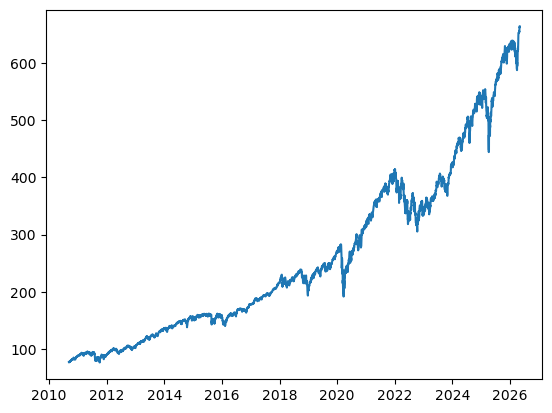

In [9]:
import matplotlib.pyplot as plt

plt.plot(df['Open'])
# plt.plot(live_data['High'])
# plt.plot(live_data['Low'])
plt.show()

In [16]:
df['SMA_50'] = df['Close'].rolling(window=50).mean()  # 50-day moving average
ath_price = df['High'].max()
ath_date = df['High'].idxmax()

# Influence of Tech Stocks

## S&P 500 Top-10 Holdings Monthly Weight Pipeline

### Build a CSV of the top 10 S&P 500 companies (by index weight) for every month from January 1993 through April 2026.

In [10]:
import pandas as pd
import os

archive_path = 'archive'
dfs = {}

for f in sorted(os.listdir(archive_path)):
    df = pd.read_csv(os.path.join(archive_path, f))
    dfs[f] = df

In [16]:
print(list(dfs.keys()))

['2000.csv', '2001.csv', '2002.csv', '2003.csv', '2004.csv', '2005.csv', '2006.csv', '2007.csv', '2008.csv', '2009.csv', '2010.csv', '2011.csv', '2012.csv', '2013.csv', '2014.csv', '2015.csv', '2016.csv', '2017.csv', '2018.csv', '2019.csv', '2020.csv', '2021.csv', '2022.csv', '2023.csv', '2024.csv', '2025.csv']


In [18]:
print(dfs['2009.csv'])

                         Company  Weight Ticker
0               Exxon Mobil Corp   3.532    XOM
1                 Microsoft Corp   2.150   MSFT
2            General Electric Co   1.869     GE
3            JPMorgan Chase & Co   1.846    JPM
4            Procter & Gamble Co   1.811     PG
..                           ...     ...    ...
495               Convergys Corp   0.013   CNXC
496                    MBIA, Inc   0.013    MBI
497                Meredith Corp   0.012    IAC
498  New York Times Co (Class A)   0.010    NYT
499         Titanium Metals Corp   0.009    PCP

[500 rows x 3 columns]


In [20]:
rows = []
for filename, df in dfs.items():
    year = int(filename.replace('.csv', ''))
    top10 = df.nlargest(10, 'Weight')[['Company', 'Ticker', 'Weight']].reset_index(drop=True)
    row = {'Year': year}
    for i, r in top10.iterrows():
        row[f'Company_{i+1}'] = r['Company']
        row[f'Ticker_{i+1}'] = r['Ticker']
        row[f'Weight_{i+1}'] = r['Weight']
    rows.append(row)

top10_df = pd.DataFrame(rows).sort_values('Year').reset_index(drop=True)
top10_df.to_csv('top10.csv')
print(top10_df)

    Year            Company_1 Ticker_1  Weight_1            Company_2  \
0   2000  General Electric Co       GE     4.525   Cisco Systems, Inc   
1   2001  General Electric Co       GE     3.917       Microsoft Corp   
2   2002  General Electric Co       GE     3.265       Microsoft Corp   
3   2003       Microsoft Corp     MSFT     3.267  General Electric Co   
4   2004  General Electric Co       GE     3.410     Exxon Mobil Corp   
5   2005     Exxon Mobil Corp      XOM     3.614  General Electric Co   
6   2006     Exxon Mobil Corp      XOM     3.316  General Electric Co   
7   2007     Exxon Mobil Corp      XOM     3.812  General Electric Co   
8   2008     Exxon Mobil Corp      XOM     3.962  General Electric Co   
9   2009     Exxon Mobil Corp      XOM     3.532       Microsoft Corp   
10  2010    Exxon Mobil Corp.      XOM     3.044          Apple, Inc.   
11  2011          Apple, Inc.     AAPL     3.431    Exxon Mobil Corp.   
12  2012          Apple, Inc.     AAPL     4.856   

In [25]:
print(top10_df[['Year', 'Ticker_1', 'Ticker_2', 'Ticker_3', 'Ticker_4', 'Ticker_5', 'Ticker_6', 'Ticker_7', 'Ticker_8', 'Ticker_9', 'Ticker_10']])

    Year Ticker_1 Ticker_2 Ticker_3 Ticker_4 Ticker_5 Ticker_6 Ticker_7  \
0   2000       GE     CSCO     MSFT      XOM      PFE     INTC        C   
1   2001       GE     MSFT      XOM      PFE      WMT      AIG        C   
2   2002       GE     MSFT      WMT      XOM      PFE      JNJ        C   
3   2003     MSFT       GE      WMT      XOM      PFE        C     INTC   
4   2004       GE      XOM     MSFT      PFE        C      WMT      AIG   
5   2005      XOM       GE     MSFT        C      JNJ      PFE      BAC   
6   2006      XOM       GE        C      BAC     MSFT      PFE       PG   
7   2007      XOM       GE        T     MSFT        C      BAC       PG   
8   2008      XOM       GE       PG     MSFT      JNJ      JPM      CVX   
9   2009      XOM     MSFT       GE      JPM       PG      JNJ     AAPL   
10  2010      XOM     AAPL     MSFT       GE      JNJ       PG      IBM   
11  2011     AAPL      XOM      IBM     MSFT      CVX      JNJ       PG   
12  2012     AAPL      XO

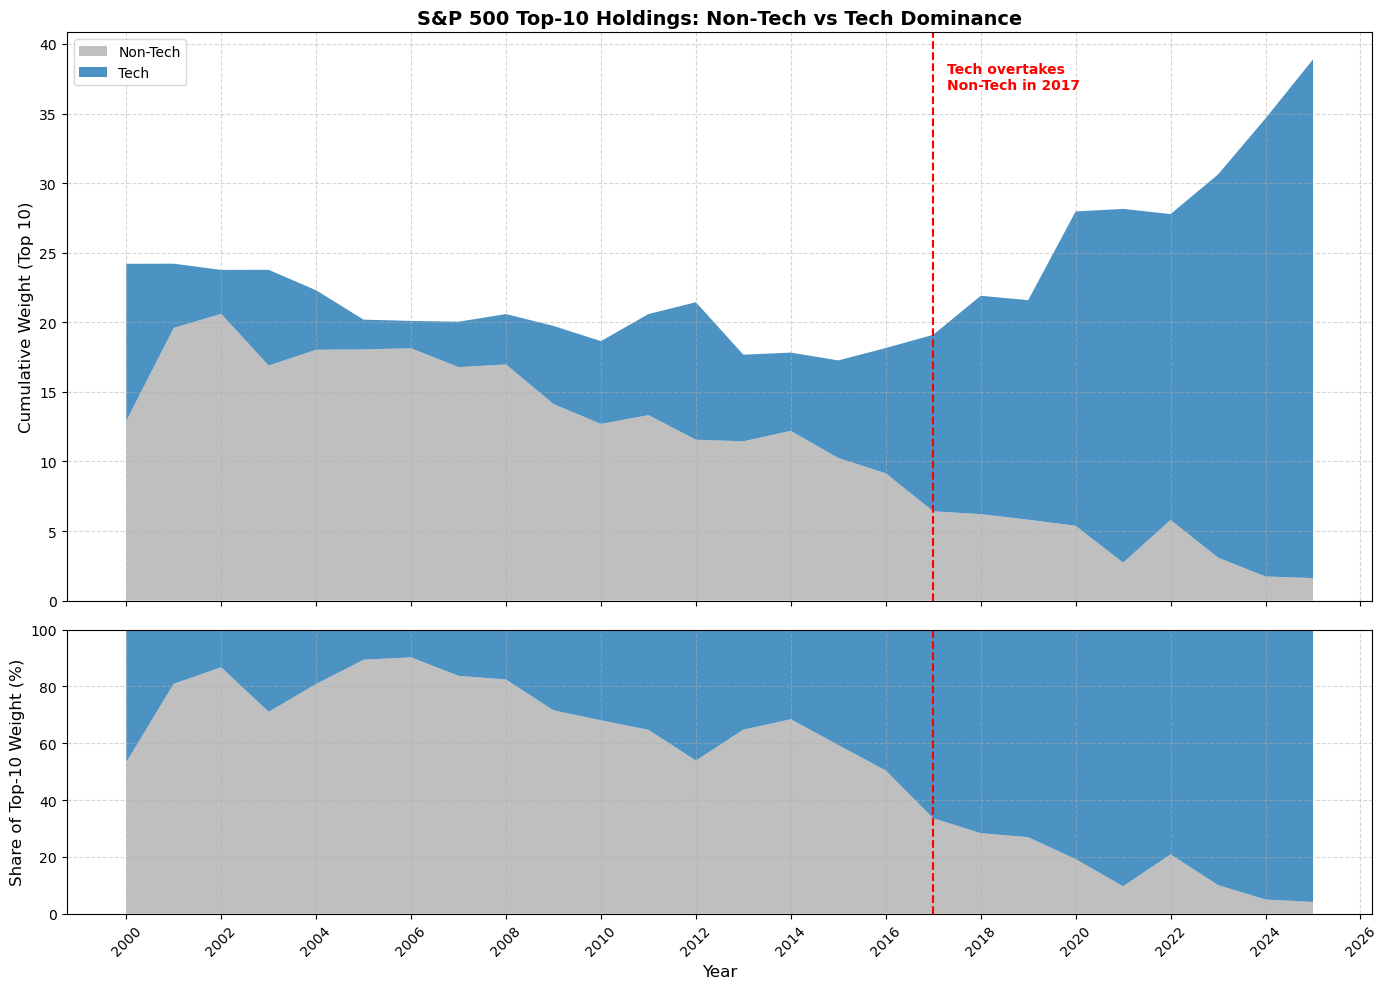

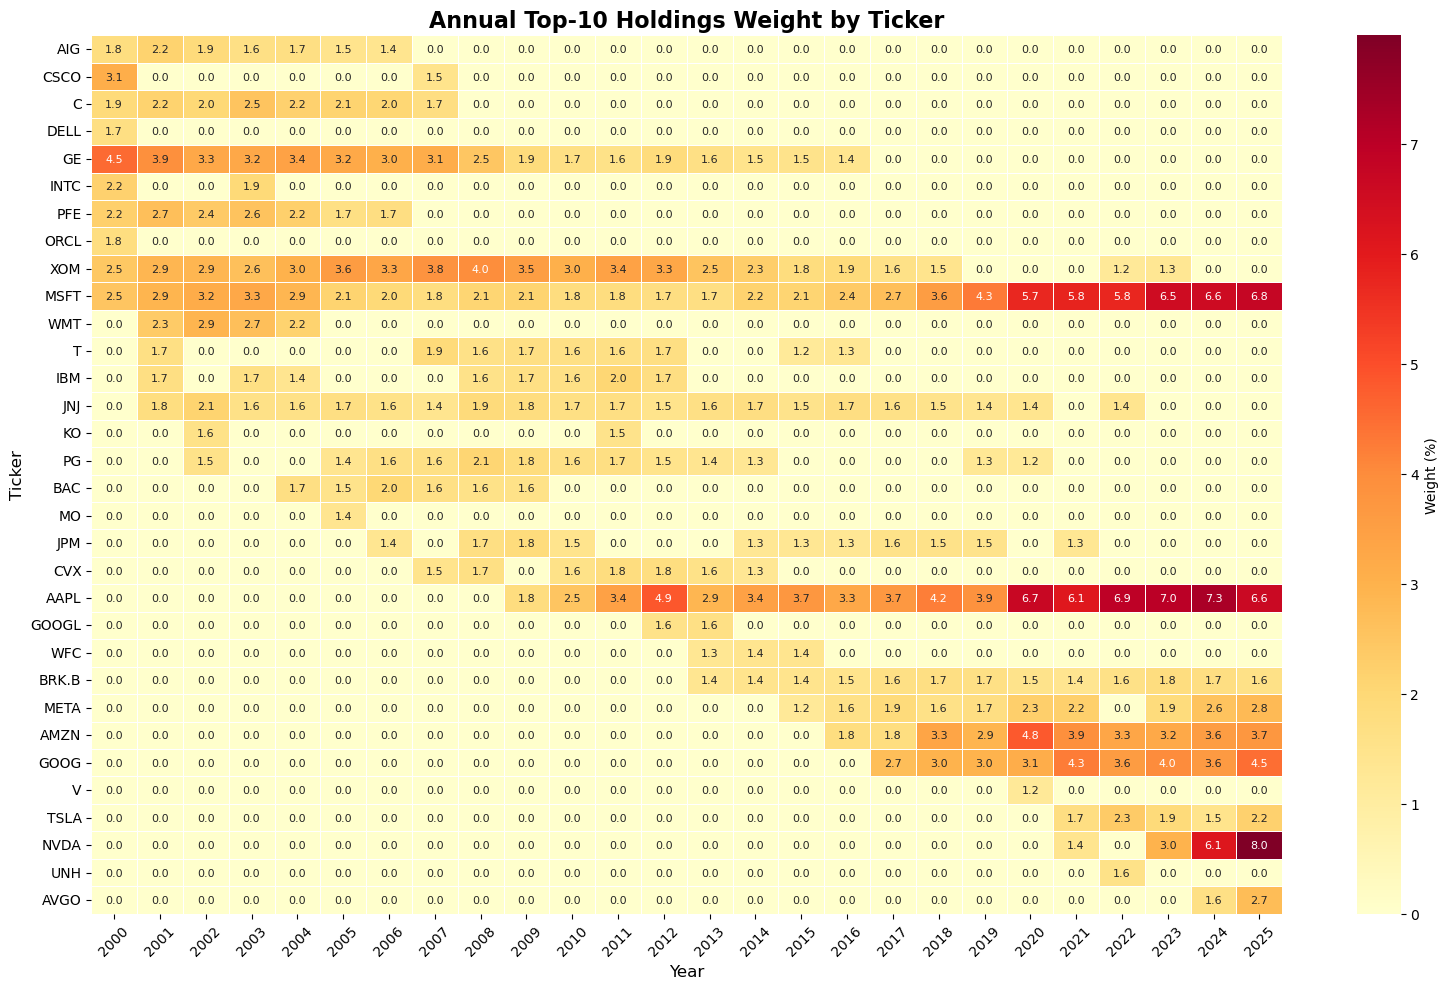

In [26]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import numpy as np

top10_df = pd.read_csv('top10.csv')

records = []
for _, row in top10_df.iterrows():
    year = row['Year']
    for rank in range(1, 11):
        ticker = row[f'Ticker_{rank}']
        weight = row[f'Weight_{rank}']
        records.append({'Year': year, 'Rank': rank, 'Ticker': ticker, 'Weight': weight})

long_df = pd.DataFrame(records)

tech_tickers = {
    'MSFT', 'AAPL', 'CSCO', 'INTC', 'ORCL', 'IBM', # early tech
    'AMZN', 'META', 'GOOG', 'GOOGL', # internet / platform
    'NVDA', 'AVGO', 'TSLA', # semiconductors / EV
    'DELL', 'HPQ'  # hardware (if present)
}

long_df['Sector'] = long_df['Ticker'].apply(lambda x: 'Tech' if x in tech_tickers else 'Non-Tech')

yearly_sector = (long_df.groupby(['Year', 'Sector'])['Weight'].sum().unstack(fill_value=0).reset_index())
if 'Tech' not in yearly_sector.columns:
    yearly_sector['Tech'] = 0
if 'Non-Tech' not in yearly_sector.columns:
    yearly_sector['Non-Tech'] = 0

yearly_sector['Total'] = yearly_sector['Tech'] + yearly_sector['Non-Tech']
yearly_sector['Tech_pct'] = 100 * yearly_sector['Tech'] / yearly_sector['Total']
yearly_sector['NonTech_pct'] = 100 * yearly_sector['Non-Tech'] / yearly_sector['Total']

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), sharex=True, gridspec_kw={'height_ratios': [2, 1]})

# absolute weights (stacked area)
ax1.stackplot(yearly_sector['Year'], yearly_sector['Non-Tech'], yearly_sector['Tech'], labels=['Non-Tech', 'Tech'], colors=['#b0b0b0', '#1f77b4'], alpha=0.8)
ax1.set_ylabel('Cumulative Weight (Top 10)', fontsize=12)
ax1.set_title('S&P 500 Top‑10 Holdings: Non‑Tech vs Tech Dominance', fontsize=14, fontweight='bold')
ax1.legend(loc='upper left', fontsize=10)
ax1.grid(True, linestyle='--', alpha=0.5)

# percentage split (stacked area 0-100%)
ax2.stackplot(yearly_sector['Year'], yearly_sector['NonTech_pct'], yearly_sector['Tech_pct'], labels=['Non-Tech %', 'Tech %'], colors=['#b0b0b0', '#1f77b4'], alpha=0.8)
ax2.set_xlabel('Year', fontsize=12)
ax2.set_ylabel('Share of Top‑10 Weight (%)', fontsize=12)
ax2.set_ylim(0, 100)
ax2.grid(True, linestyle='--', alpha=0.5)

# Mark the year when Tech first exceeds Non-Tech (if any)
cross_year = yearly_sector[yearly_sector['Tech'] > yearly_sector['Non-Tech']]['Year'].min()
if pd.notna(cross_year):
    ax1.axvline(x=cross_year, color='red', linestyle='--', linewidth=1.5)
    ax2.axvline(x=cross_year, color='red', linestyle='--', linewidth=1.5)
    ax1.text(cross_year + 0.3, ax1.get_ylim()[1]*0.9, f'Tech overtakes\nNon-Tech in {int(cross_year)}', color='red', fontsize=10, fontweight='bold')

for ax in [ax1, ax2]:
    ax.xaxis.set_major_locator(mticker.MultipleLocator(2))
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
# plt.savefig('tech_vs_nonteach_shift.png', dpi=150, bbox_inches='tight')
plt.show()

pivot = long_df.pivot_table(index='Ticker', columns='Year', values='Weight', aggfunc='sum', fill_value=0)

first_year = long_df.groupby('Ticker')['Year'].min().sort_values()
pivot = pivot.loc[first_year.index]

plt.figure(figsize=(16, 10))
sns.heatmap(pivot, annot=True, fmt='.1f', cmap='YlOrRd',
            linewidths=.5, cbar_kws={'label': 'Weight (%)'},
            annot_kws={'size': 8})
plt.title('Annual Top‑10 Holdings Weight by Ticker', fontsize=16, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Ticker', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
# plt.savefig('top10_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()